In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [19]:
data = pd.read_csv("../data/kaggle_b2_fraud_train_v3.csv")

In [20]:
df = data.copy()
df

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,partner_risk_indicator,manual_review_result,post_event_status_code,chargeback_resolution_time_days,legacy_partner_score
0,CUST_6O9Q8D4I36,ACC_TXXXTNEUVKFY,34,108,38635.01,544.0,20,60.92,80.16,4.9,...,0.39006,0.10963,0.55097,-0.56104,1,NaN,approve,0,7.9,NaN
1,CUST_FGUGTW230C,ACC_70VD7A4FFWCW,48,2,19912.97,703.0,21,112.11,571.12,0.3,...,0.03265,-0.40256,0.36218,0.86583,1,NaN,approve,0,5.5,NaN
2,CUST_8ZI3LCBZ0W,ACC_AF53381QSC0L,27,0,20326.87,720.0,25,73.61,492.57,4.6,...,-0.15637,0.57818,0.28902,-2.19864,1,NaN,approve,0,7.2,NaN
3,CUST_5MP3AR41CJ,ACC_U7WZGJ486LIV,45,49,38452.47,703.0,17,47.53,204.18,25.3,...,-1.02145,0.63908,-0.89190,-0.81592,1,NaN,approve,0,4.4,NaN
4,CUST_GNPL83JB0J,ACC_XW7DS3ED5J4Y,37,46,NaN,594.0,13,99.95,734.09,12.8,...,-0.65771,0.08020,0.17606,0.86739,1,NaN,approve,0,4.9,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,CUST_I81IW5SVRQ,ACC_UPDTFTYTSM0A,56,0,34775.62,727.0,21,51.72,226.11,3.8,...,-2.54086,-0.60747,0.23252,-0.06215,1,-1.535486,approve,0,1.0,NaN
159996,CUST_QT6DDEMKTJ,ACC_97NE0LBL5W9U,41,4,88617.57,770.0,18,NaN,171.07,15.1,...,0.34098,-1.78817,0.31788,0.51072,1,NaN,approve,0,7.4,NaN
159997,CUST_I0JS1GTS98,ACC_9JJ84W64Z7GX,30,2,41148.54,738.0,20,29.34,119.81,0.7,...,-1.28947,-0.32324,-0.06238,-0.99076,1,NaN,approve,3,6.6,NaN
159998,CUST_L7GUCJ3TFY,ACC_NGFXDR7HW1ZS,56,6,NaN,719.0,25,88.56,553.16,22.6,...,0.47179,-0.22090,-1.34239,-0.30513,1,NaN,approve,0,12.5,NaN


# Preprocessing

## 1. Nettoyage des colonnes

In [21]:
df = df[df.columns[df.isna().sum()/df.shape[0] <0.9]]
df.head()

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_3,internal_signal_4,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,manual_review_result,post_event_status_code,chargeback_resolution_time_days
0,CUST_6O9Q8D4I36,ACC_TXXXTNEUVKFY,34,108,38635.01,544.0,20,60.92,80.16,4.9,...,-0.68676,-1.54627,0.39006,0.10963,0.55097,-0.56104,1,approve,0,7.9
1,CUST_FGUGTW230C,ACC_70VD7A4FFWCW,48,2,19912.97,703.0,21,112.11,571.12,0.3,...,-0.17429,-0.00054,0.03265,-0.40256,0.36218,0.86583,1,approve,0,5.5
2,CUST_8ZI3LCBZ0W,ACC_AF53381QSC0L,27,0,20326.87,720.0,25,73.61,492.57,4.6,...,-0.86064,-0.32183,-0.15637,0.57818,0.28902,-2.19864,1,approve,0,7.2
3,CUST_5MP3AR41CJ,ACC_U7WZGJ486LIV,45,49,38452.47,703.0,17,47.53,204.18,25.3,...,-1.11761,1.35968,-1.02145,0.63908,-0.89190,-0.81592,1,approve,0,4.4
4,CUST_GNPL83JB0J,ACC_XW7DS3ED5J4Y,37,46,NaN,594.0,13,99.95,734.09,12.8,...,0.11581,1.65795,-0.65771,0.08020,0.17606,0.86739,1,approve,0,4.9


In [22]:
df = df.drop(columns=["customer_id", "account_id"]) # N'apporte pas d'informations pour les futurs modèles

In [23]:
df = df.drop(columns=["customer_note"]) # Contient une série de mot libre qui ne nous eet pas pendant le preprocess

                         income_log  annual_income_eur  \
income_log                 1.000000           0.763881   
annual_income_eur          0.763881           1.000000   
income_estimate_alt_eur    0.925534           0.822232   

                         income_estimate_alt_eur  
income_log                              0.925534  
annual_income_eur                       0.822232  
income_estimate_alt_eur                 1.000000  


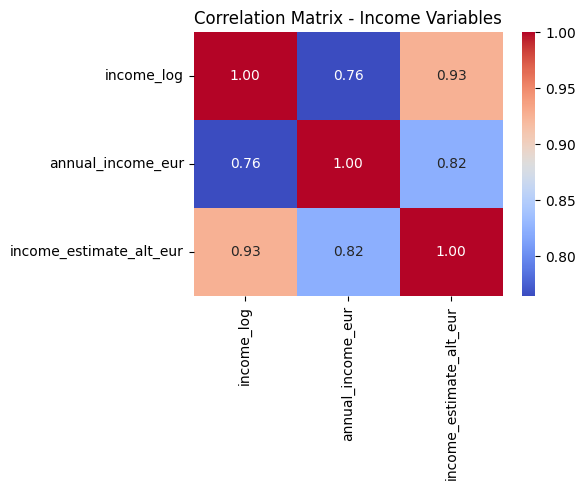

In [24]:
cols = [
    "income_log",
    "annual_income_eur",
    "income_estimate_alt_eur"
]

# Matrice de corrélation
corr_matrix = df[cols].corr(method="pearson")

print(corr_matrix)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Income Variables")
plt.tight_layout()
plt.show()

In [25]:
df = df.drop(columns=["income_estimate_alt_eur"])

## 2. Split Temporel

In [26]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df = df.sort_values("signup_date")

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()


## 3. Imputation

In [27]:
target = "target_is_fraud"

num_cols = train.select_dtypes(include=["int64","float64"]).columns.drop(target)
cat_cols = train.select_dtypes(include=["object","category"]).columns

In [28]:
medians = train[num_cols].median()

train[num_cols] = train[num_cols].fillna(medians)
test[num_cols] = test[num_cols].fillna(medians)


In [29]:
train[cat_cols] = train[cat_cols].fillna("MISSING")
test[cat_cols] = test[cat_cols].fillna("MISSING")


## 4. Target Encoding

In [30]:

for col in cat_cols:
    means = train.groupby(col)[target].mean()
    
    train[col + "_te"] = train[col].map(means)
    test[col + "_te"] = test[col].map(means)
    
    test[col + "_te"] = test[col + "_te"].fillna(train[target].mean())


In [31]:
train = train.drop(columns=cat_cols)
test = test.drop(columns=cat_cols)

## 5. Scaling

In [32]:
feature_cols = train.columns.drop([target, "signup_date"])

scaler = StandardScaler()

train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols] = scaler.transform(test[feature_cols])


In [36]:
train.to_csv("../data/data_preprocess_train_v1.csv")

In [35]:
test.to_csv("../data/data_preprocess_test_v1.csv")